# Do diverse topic ties predict concept spread? — co-occurrence screen demo

This notebook is a runnable walk-through of the experiment's `method.py`. It screens two **co-occurrence emergence indicators**
against a strong baseline on the frozen **P78 dev panel** (47 dev concepts: BIO 16, CS 12, MED 10, ENG 9):

* **D (structural diversity):** do the *new* topic neighbours of an emerging concept come from many distinct communities of
  the topic backbone? The primary D is `D_ratio` (distinct communities of new neighbours / frequency-matched null mean).
* **F (frequency-free selectivity):** `F_res`, the growth of the concept's topic selectivity minus a size-matched null.
* **B5 baseline:** `logvol, growth, offhome_share, entropy, nfields2`.
* **Main outcome O2r:** rarefied venue-field richness (m=30) a few years after onset (how widely the concept spread).

`method.py` is an orchestrator that runs 9 steps as subprocesses. Steps 1–6 need the OpenAlex API and a
column-pruned scan of **all 476M works** of the OpenAlex S3 snapshot, so they cannot run in a notebook. This demo therefore:

1. shows the orchestrator (`STEPS`, `DEVIATIONS`, `run`) exactly as in `method.py`, and
2. **executes step 7 (`screen`)**, the statistical core, on the precomputed per-concept tables those upstream
   steps produced (`outcomes.csv`, `features_ego.csv`, `field_*.csv`, `reliability_splits.csv`), bundled in
   `mini_demo_data.json`.

The screen fits leave-one-home-field-group-out (LOGO) ridge/logistic models, B5 vs B5 + candidate, runs a stratified
concept bootstrap, and applies the pre-registered selection rule. The headline result in the original run (2,000 bootstraps) is
**B5 ρ = 0.770; D_ratio Δρ = +0.006 [90% CI −0.092, 0.135]; F_res Δρ = −0.060 [−0.158, 0.014]; no candidate survives.**

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports
The import blocks of `method.py` and `screen.py` (the `from config import ...` lines are replaced by the constants in the config
cell below), plus `matplotlib` for the final plots.

In [2]:
from __future__ import annotations

import os

for _v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")  # tiny models: avoid BLAS thread oversubscription across bootstrap workers

# --- method.py
import argparse
import json
import resource
import subprocess
import sys
import time

from loguru import logger

# --- screen.py
import math
import multiprocessing as mp
import warnings
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# --- notebook additions
import matplotlib.pyplot as plt
from pathlib import Path

## Load the data
`mini_demo_data.json` holds the per-concept tables written by steps 4–6 of the pipeline (78 panel rows in `outcomes`,
of which 47 are dev concepts; 129 concept×field rows; 50 paper-level split-half draws per concept), plus the original run's
headline numbers (`reference_screen_result`) for comparison.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_-IpcIodNqp66/round-1/experiment-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: len(v) for k, v in data.items() if isinstance(v, list)})

{'outcomes': 78, 'features_ego': 47, 'field_outcomes_base': 129, 'field_features': 129, 'reliability_splits': 2350}


## Config
Tunable parameters. The original run used `N_BOOT = 2000` concept bootstraps (the reach30 hurdle and the sensitivity
analyses use `min(1000, N_BOOT)`) with 4 spawn-process workers. In a notebook, spawn workers cannot import functions
defined in the notebook, so the bootstrap runs serially (`N_WORKERS = 1`). `N_BOOT` is kept at the original 2000 (the whole screen takes about 2.5 min serially), so the bootstrap CIs reproduce the original run.
The other constants are copied from the original `config.py`.

In [5]:
N_BOOT = 2000        # original: 2000 (config.N_BOOT) — full original value; ~2.5 min serial. Use 20-200 for a quick look (CIs then approximate)
SEED = 20260928      # original: config.SEED
N_WORKERS = 1        # original: 4 (ProcessPoolExecutor, spawn); 1 = serial bootstrap in the notebook

# ---- frozen constants from config.py
DEV_FIELDS = {17: "Computer Science", 22: "Engineering", 13: "Biochemistry, Genetics and Molecular Biology",
              27: "Medicine"}
GROUP_SHORT = {17: "CS", 22: "ENG", 13: "BIO", 27: "MED"}
DROPPED_ALIASES = [{"concept": "natural orifice transluminal endoscopic surgery", "alias": "NOTES",
                    "reason": "common English word; case-insensitive stemmed phrase search would match 'notes'"}]

## The `method.py` orchestrator
The pipeline steps and the list of documented protocol deviations, verbatim from `method.py`. `run()` launches each step as
`python <step>.py` in the artifact directory. It is defined here for reference but **not called**. Instead of running
steps 1–6, the notebook takes their outputs from `data`, and step 7 (`screen`) is executed inline below.

In [6]:
PY = sys.executable
STEPS = ["s0_fetch", "snapshot_meta", "scan_snapshot", "s0_outcomes", "backbone", "features", "screen",
         "extra_analyses", "make_outputs"]

DEVIATIONS = DROPPED_ALIASES + [
    {"id": "API_KEY_EXHAUSTED", "what": "The shared OpenAlex key had 0 credits left (x-ratelimit-remaining=0, reset "
     "~11.7 h) when this artifact started. API use was limited to the S0 yearly counts (78 concepts + global + OR test, "
     "156 credits in total) on the public per-IP anonymous pool (1,000/day; >= 800 left for siblings).",
     "consequence": "All other data (venue windows, ego networks, backbone, background prevalence) come from the free "
     "OpenAlex S3 works snapshot (2026-09-23; 476M works) at 0 credits."},
    {"id": "TITLE_GROUNDING_FOR_COMPOSITION", "what": "Venue-field compositions (home field, O2r, R_j, early "
     "off-home share/entropy/reach) and ego topic counts use TITLE-matched base works from the snapshot "
     "(OpenAlex-like analysis: lowercase, possessive strip, stop words with position gaps, Porter stemming, "
     "positional phrase match), not title+abstract matches, because abstracts are 43% of the snapshot bytes. "
     "t0, newborn, O1, O3, log volume and growth use the S0-exact API title+abstract counts.",
     "consequence": "Lower recall (see sanity.median_title_share_of_api_early), higher topical precision; field "
     "compositions are estimated from the papers that name the concept in the title."},
    {"id": "HOME_WINDOW_WIDENED", "what": "If fewer than 5 labelled title-matched papers exist in t0..t0+1, the home "
     "field is decided on t0..t0+2 (flag home_window in outcomes.csv)."},
    {"id": "FULL_CORPUS_BACKBONE", "what": "The backbone uses ALL base works of each slice (millions) instead of "
     "10k-work samples, and exact yearly background prevalence instead of slice-level log-linear interpolation "
     "(plan departures 2 and 3 are removed)."},
    {"id": "GAMMA_RULE", "what": "On the dense full-corpus backbone the plan's rule (gamma maximising median standard "
     "modularity) picks gamma=1, which leaves only ~8 communities of ~500 topics, outside the plan's expected 'tens to a "
     "few hundred' (T2). BEFORE any outcome was inspected, the primary gamma was redefined as the highest-median-Q gamma "
     "whose median number of non-trivial communities is >= 20; the plan-rule partition is reported as D_q."},
    {"id": "SELF_TOPIC_LEXICAL_RULE", "what": "A literal 'shares one content lemma' rule flagged generic topics as "
     "SELF (e.g. 'cell' -> 30 topics for iPSC, 'sensing' -> Remote Sensing for compressed sensing, 'comparative' -> "
     "legal studies). The lexical SELF rule was tightened (before outcomes were inspected) to: the topic name contains "
     "ALL content lemmas (lemma occurring in <= 100 topic names) of at least one of the concept's phrases; the >= 20% "
     "paper-share rule is unchanged. 16 of 47 dev concepts get a lexical self topic (e.g. compressed sensing -> "
     "'Sparse and Compressive Sensing Techniques')."},
    {"id": "D_PRIMARY_FALLBACK_T3", "what": "T3 STOP-AND-FIX fired: 70% of dev concepts have D_z < -5 and "
     "Spearman(D_z, M) = -0.69 (with log early volume -0.63): the frequency-matched null draws from all of science "
     "while real neighbours are topically concentrated, so z scales with M. Per the plan's pre-stated fallback, and "
     "decided on outcome-blind diagnostics only, the primary D is the one of D_ratio / D_rare with the smaller "
     "|Spearman| with M: D_ratio (obs distinct communities / null mean; 0.23 vs 0.29). D_z is still screened and "
     "reported as 'D_z_literal' (not ranked)."},
    {"id": "SPLIT_HALF_PAPER_LEVEL", "what": "Split-half reliability uses real paper-level random halves (paper topic "
     "lists are available from the snapshot) instead of binomial thinning of aggregate counts (plan departure 7)."},
    {"id": "EGO_WINDOWS_EXACT", "what": "Ego windows are exact paper sets per year, so first-appearance years of new "
     "neighbours are yearly (plan departure 4 no longer binds)."},
    {"id": "CENTRALITY_ON_KNN_BACKBONE", "what": "Betweenness/k-core/constraint of the inserted concept node are "
     "computed on a kNN-sparsified (top-10 PMI edges per topic), unweighted copy of the slice backbone, for runtime."},
    {"id": "COMPRESSED_SENSING_ALIAS", "what": "The OR-syntax test showed 'compressed sensing' and 'compressive "
     "sensing' return identical counts (same Porter stem), so the alias adds nothing; the pipe syntax was frozen."},
]


def run(step: str, extra: list[str]) -> None:
    t = time.time()
    cmd = [PY, str(ROOT / f"{step}.py")] + extra  # ROOT = the artifact directory (not available in the notebook)
    logger.info(f"=== {step}: {step}.py {' '.join(extra)}")
    r = subprocess.run(cmd, cwd=ROOT)
    if r.returncode != 0:
        raise RuntimeError(f"step {step} failed with exit code {r.returncode}")
    logger.info(f"=== {step} done in {(time.time() - t) / 60:.1f} min")


logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
for i, s in enumerate(STEPS, 1):
    print(f"{i}. {s:15s} {'<- executed inline in this notebook' if s == 'screen' else '(output taken from data)' if i < 7 else '(not run)'}")
print(f"\n{len(DEVIATIONS)} documented deviations:", [d.get("id", d.get("alias")) for d in DEVIATIONS])

1. s0_fetch        (output taken from data)
2. snapshot_meta   (output taken from data)
3. scan_snapshot   (output taken from data)
4. s0_outcomes     (output taken from data)
5. backbone        (output taken from data)
6. features        (output taken from data)
7. screen          <- executed inline in this notebook
8. extra_analyses  (not run)
9. make_outputs    (not run)

12 documented deviations: ['NOTES', 'API_KEY_EXHAUSTED', 'TITLE_GROUNDING_FOR_COMPOSITION', 'HOME_WINDOW_WIDENED', 'FULL_CORPUS_BACKBONE', 'GAMMA_RULE', 'SELF_TOPIC_LEXICAL_RULE', 'D_PRIMARY_FALLBACK_T3', 'SPLIT_HALF_PAPER_LEVEL', 'EGO_WINDOWS_EXACT', 'CENTRALITY_ON_KNN_BACKBONE', 'COMPRESSED_SENSING_ALIAS']


## Step 7 `screen` — models
From here on the code is `screen.py`. Candidates and baseline:
* `B5`: the concept-level baseline; `BF`: the field-level baseline for the field-adoption outcome R_j.
* `PRIMARY`: the screened candidates. `D_ratio` replaced the plan's literal `D_z` after the pre-declared T3 size diagnostic failed.

The models are a standardised ridge (α=1) for the continuous O2r and an exact Newton-Raphson L2 logistic regression (the sklearn
`C=1` objective) for binary outcomes. Missing candidate values are median-imputed from the training fold, with a missing-indicator column.
`logo()` trains on 3 home groups and predicts the 4th.

In [7]:
warnings.filterwarnings("ignore")
B5 = ["logvol", "growth", "offhome_share", "entropy", "nfields2"]
BF = ["logn_j_early", "growth_j", "share_j"]
# D: the plan's literal primary D_z failed the T3 STOP-AND-FIX size diagnostic (70% of D_z < -5,
# Spearman(D_z, M) = -0.69, with log volume -0.63; computed before any outcome was inspected), so the pre-declared
# fallback (the one of D_ratio / D_rare with the smaller |Spearman| with M) is primary: D_ratio (0.23 vs 0.29).
# D_z is still screened and reported as 'D_z_literal'.
PRIMARY = {"D": "D_ratio", "F": "F_res", "D_z_literal": "D_z"}
SCREENED = ("D", "F")


# ----------------------------------------------------------------------------- models
def _prep(Xtr: np.ndarray, Xte: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Median-impute (train medians) + missing flags for columns with NaN, then standardise on train."""
    Xtr = Xtr.astype(float).copy()
    Xte = Xte.astype(float).copy()
    flags_tr, flags_te = [], []
    for j in range(Xtr.shape[1]):
        mtr, mte = np.isnan(Xtr[:, j]), np.isnan(Xte[:, j])
        if mtr.any() or mte.any():
            med = np.nanmedian(Xtr[:, j]) if (~mtr).any() else 0.0
            Xtr[mtr, j] = med
            Xte[mte, j] = med
            if mtr.any() and (~mtr).any():
                flags_tr.append(mtr.astype(float))
                flags_te.append(mte.astype(float))
    if flags_tr:
        Xtr = np.column_stack([Xtr] + flags_tr)
        Xte = np.column_stack([Xte] + flags_te)
    mu = Xtr.mean(0)
    sd = Xtr.std(0)
    sd[sd == 0] = 1.0
    return (Xtr - mu) / sd, (Xte - mu) / sd


def ridge_fit_predict(Xtr, ytr, Xte, alpha: float = 1.0) -> np.ndarray:
    Xtr, Xte = _prep(Xtr, Xte)
    ym = ytr.mean()
    A = Xtr.T @ Xtr + alpha * np.eye(Xtr.shape[1])
    beta = np.linalg.solve(A, Xtr.T @ (ytr - ym))
    return ym + Xte @ beta


def logit_newton(X: np.ndarray, y: np.ndarray, C: float = 1.0, iters: int = 100, tol: float = 1e-10) -> np.ndarray:
    """Exact minimiser of 0.5*||w||^2 + C*sum(logloss) with an unpenalised intercept (the sklearn
    LogisticRegression(C=1) objective), by Newton-Raphson; returns [b, w]."""
    n, p = X.shape
    Z = np.column_stack([np.ones(n), X])
    beta = np.zeros(p + 1)
    R = np.eye(p + 1) / C
    R[0, 0] = 0.0
    for _ in range(iters):
        eta = Z @ beta
        mu = 1.0 / (1.0 + np.exp(-eta))
        g = Z.T @ (mu - y) + R @ beta
        H = (Z * (mu * (1 - mu))[:, None]).T @ Z + R + 1e-12 * np.eye(p + 1)
        step = np.linalg.solve(H, g)
        beta -= step
        if np.abs(step).max() < tol:
            break
    return beta


def logit_fit_predict(Xtr, ytr, Xte) -> np.ndarray:
    if len(np.unique(ytr)) < 2:
        return np.full(len(Xte), ytr.mean())
    Xtr, Xte = _prep(Xtr, Xte)
    beta = logit_newton(Xtr, ytr.astype(float))
    return 1.0 / (1.0 + np.exp(-(beta[0] + Xte @ beta[1:])))


def logit_fit_predict_sklearn(Xtr, ytr, Xte) -> np.ndarray:
    """Reference implementation (used only in the equivalence check)."""
    Xtr, Xte = _prep(Xtr, Xte)
    m = LogisticRegression(C=1.0, max_iter=5000, tol=1e-10)
    m.fit(Xtr, ytr)
    return m.predict_proba(Xte)[:, 1]


def logo(X: np.ndarray, y: np.ndarray, groups: np.ndarray, kind: str) -> np.ndarray:
    oof = np.full(len(y), np.nan)
    for g in np.unique(groups):
        te = groups == g
        tr = ~te
        if tr.sum() < 5:
            continue
        f = ridge_fit_predict if kind == "ridge" else logit_fit_predict
        oof[te] = f(X[tr], y[tr], X[te])
    return oof


def srho(a, b) -> float:
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3 or np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return float("nan")
    return float(spearmanr(a[m], b[m]).statistic)


def auc(y, p) -> float:
    m = np.isfinite(p) & np.isfinite(y)
    if m.sum() < 3 or len(np.unique(y[m])) < 2:
        return float("nan")
    return float(roc_auc_score(y[m], p[m]))

### One evaluation (point estimate or one bootstrap replicate), and the bootstrap
* `eval_concept`: for each outcome, the LOGO metric of B5 (Spearman ρ for O2r, AUC for binary outcomes) and the **delta** each
  candidate adds (`metric(B5 + c) − metric(B5)`), under identical folds.
* `eval_field`: the same for the concept×field adoption outcome R_j (field-level baseline `BF`).
* `bootstrap`: resamples **concepts** stratified by home group and refits the whole LOGO in every replicate.

**Only change from the original:** `bootstrap` gains a serial path for `n_workers <= 1`. It uses the same seeds and chunks as the
original, just `map` instead of `ProcessPoolExecutor`, because spawn workers cannot unpickle functions defined in a notebook.

In [8]:
def eval_concept(df: pd.DataFrame, cands: list[str], base_cols: list[str], outcomes: dict[str, str],
                 per_group: bool = False) -> dict:
    """Returns {outcome: {'base': metric, cand: delta, ...}} (+ per-group deltas for continuous outcomes)."""
    res = {}
    g = df["group"].to_numpy()
    for oname, kind in outcomes.items():
        d = df[np.isfinite(df[oname].to_numpy(dtype=float))]
        if len(d) < 8:
            continue
        y = d[oname].to_numpy(dtype=float)
        gg = d["group"].to_numpy()
        Xb = d[base_cols].to_numpy(dtype=float)
        pb = logo(Xb, y, gg, "ridge" if kind == "cont" else "logit")
        metric = srho if kind == "cont" else auc
        mb = metric(pb, y) if kind == "cont" else metric(y, pb)
        r = {"base": mb}
        for c in cands:
            Xc = d[base_cols + [c]].to_numpy(dtype=float)
            pc_ = logo(Xc, y, gg, "ridge" if kind == "cont" else "logit")
            mc = metric(pc_, y) if kind == "cont" else metric(y, pc_)
            r[c] = mc - mb
            if per_group:
                pg = {}
                for grp in np.unique(gg):
                    m = gg == grp
                    if kind == "cont":
                        pg[grp] = srho(pc_[m], y[m]) - srho(pb[m], y[m])
                    else:
                        pg[grp] = auc(y[m], pc_[m]) - auc(y[m], pb[m])
                r[c + "__per_group"] = pg
                r[c + "__oof"] = pc_.tolist()
        if per_group:
            r["base__oof"] = pb.tolist()
            r["index"] = d["concept"].tolist()
        res[oname] = r
    del g
    return res


def eval_field(fdf: pd.DataFrame, cands: list[list[str]]) -> dict:
    y = fdf["R_j"].to_numpy(dtype=float)
    gg = fdf["group"].to_numpy()
    pb = logo(fdf[BF].to_numpy(dtype=float), y, gg, "logit")
    r = {"base": auc(y, pb)}
    for cc in cands:
        pc_ = logo(fdf[BF + cc].to_numpy(dtype=float), y, gg, "logit")
        r["+".join(cc)] = auc(y, pc_) - r["base"]
    return r


def strat_resample(df: pd.DataFrame, rng) -> pd.DataFrame:
    parts = []
    for _, d in df.groupby("group"):
        idx = rng.integers(0, len(d), len(d))
        parts.append(d.iloc[idx])
    return pd.concat(parts, ignore_index=True)


def _boot_worker(args):
    df, fdf, cands, base_cols, outcomes, field_cands, seeds = args
    out = []
    for sd in seeds:
        rng = np.random.default_rng(int(sd))
        bdf = strat_resample(df, rng)
        r = {"concept": eval_concept(bdf, cands, base_cols, outcomes)}
        if fdf is not None:
            # concept-clustered: resample concepts within group, take all their field rows
            parts = []
            for c in bdf["concept"]:
                parts.append(fdf[fdf.concept == c])
            bf = pd.concat(parts, ignore_index=True) if parts else fdf.iloc[:0]
            r["field"] = eval_field(bf, field_cands) if len(bf) > 10 else {}
        out.append(r)
    return out


def bootstrap(df, fdf, cands, base_cols, outcomes, field_cands, n_boot, seed, n_workers=4):
    seeds = np.random.default_rng(seed).integers(0, 2**31 - 1, n_boot)
    chunks = np.array_split(seeds, n_workers * 4)
    res = []
    if n_workers <= 1:  # notebook: serial (spawn workers cannot import notebook-defined functions)
        for part in map(_boot_worker, [(df, fdf, cands, base_cols, outcomes, field_cands, ch) for ch in chunks]):
            res.extend(part)
        return res
    with ProcessPoolExecutor(n_workers, mp_context=mp.get_context("spawn")) as ex:
        for part in ex.map(_boot_worker, [(df, fdf, cands, base_cols, outcomes, field_cands, ch) for ch in chunks]):
            res.extend(part)
    return res


def ci(vals, lo, hi):
    v = np.asarray([x for x in vals if x is not None and np.isfinite(x)])
    if len(v) < 20:
        return [float("nan"), float("nan")]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]

### Reliability, diagnostics and the pre-registered selection rule
* `reliability`: Spearman–Brown-corrected split-half reliability from 50 paper-level random halves per concept.
* `estimable`: a binary outcome can be estimated under LOGO only if positives and negatives each occur in at least 2 home groups.
* `selection`: a candidate **survives** only if **all** of these hold: Δρ ≥ 0.10, lower 90% CI bound > 0, positive Δρ in at least 3 of 4 groups,
  SB ≥ 0.6, and |ρ| with log volume and with growth both ≤ 0.6.

In [9]:
def reliability(rel: pd.DataFrame, col: str, concepts: list[str]) -> dict:
    rs = []
    rel = rel[rel.concept.isin(concepts)]
    for _, d in rel.groupby("split"):
        a, b = d[f"{col}_A"].to_numpy(float), d[f"{col}_B"].to_numpy(float)
        r = srho(a, b)
        if np.isfinite(r):
            rs.append(r)
    if not rs:
        return {"SB_median": float("nan")}
    rs = np.array(rs)
    sb = 2 * rs / (1 + rs)
    return {"r_half_median": float(np.median(rs)), "SB_median": float(np.median(sb)),
            "SB_IQR": [float(np.percentile(sb, 25)), float(np.percentile(sb, 75))], "n_splits": int(len(rs)),
            "method": "paper-level random halves of each concept's title-matched works (t0-3..t0+4), 200 null draws"}


def kendall_w(mat: np.ndarray) -> float:
    """mat: raters x items (scores); W over rankings of items, raters = groups."""
    mat = mat[:, np.all(np.isfinite(mat), axis=0)]
    m, n = mat.shape
    if n < 3 or m < 2:
        return float("nan")
    ranks = np.array([pd.Series(row).rank().to_numpy() for row in mat])
    R = ranks.sum(0)
    S = ((R - R.mean()) ** 2).sum()
    return float(12 * S / (m ** 2 * (n ** 3 - n)))


# ----------------------------------------------------------------------------- main
INDICATORS = ["D_z", "D_ratio", "D_rare", "D_sub", "D_lag", "D_withself", "D_q", "M", "F_res", "F_z", "F_bg",
              "F_obs_growth", "NOV", "NOV_res", "deg_growth", "str_growth", "new_edge_rate", "edge_persistence",
              "turnover", "participation", "n_comm_W3", "comm_transitions", "ego_density_change", "btw_t0", "btw_t4",
              "btw_change", "kcore_t4", "constraint_t4", "constraint_change"] + B5


def estimable(df: pd.DataFrame, o: str) -> bool:
    """A binary outcome is LOGO-estimable only if positives and negatives occur in >= 2 home groups each."""
    d = df[df[o].notna()]
    pos = d[d[o] == 1].group.nunique()
    neg = d[d[o] == 0].group.nunique()
    return pos >= 2 and neg >= 2


def selection(c: dict) -> dict:
    crit = {"delta_rho>=0.10": c["delta_rho"] >= 0.10,
            "CI90_low>0": c["CI90"][0] > 0,
            ">=3/4 groups positive": c["n_groups_positive"] >= 3,
            "SB>=0.6": (c["reliability"].get("SB_median", float("nan")) or 0) >= 0.6,
            "|rho_logvol|<=0.6": abs(c["rho_logvol"]) <= 0.6,
            "|rho_growth|<=0.6": abs(c["rho_growth"]) <= 0.6}
    crit = {k: bool(v) if v == v else False for k, v in crit.items()}
    return {"criteria": crit, "survives": all(crit.values())}

## Running `screen.main()` step by step
The body of `screen.main()` follows, split across cells at top level. (The `n_boot`, `seed` and `n_workers` arguments come
from the config cell. The `pd.read_csv(RES / ...)` calls read from `data`, and the CSV/JSON writes to `results/` are skipped.)

### Build the dev table and the field-level table
Dev concepts are panel concepts with no `dropped_reason` (t0 in 2003–2009 and home field in CS/ENG/BIO/MED). `O2r_top` marks
the top tercile of O2r. The main analysis uses dev concepts that have an O2r.

In [10]:
n_boot, seed, n_workers = N_BOOT, SEED, N_WORKERS
_t_start = time.time()
out = pd.DataFrame(data["outcomes"])                 # original: pd.read_csv(RES / "outcomes.csv")
fe = pd.DataFrame(data["features_ego"])              # original: pd.read_csv(RES / "features_ego.csv")
dev = out[out.dropped_reason.isna() | (out.dropped_reason == "")].merge(fe, on="concept", how="left")
dev["group"] = dev["group_id"].map(GROUP_SHORT)
feats_cols = ["concept", "t0", "newborn", "group"] + B5 + [c for c in fe.columns if c != "concept"]
# dev[feats_cols].to_csv(RES / "features.csv", index=False)   # (original write, skipped in the notebook)
# field-level table
fo = pd.DataFrame(data["field_outcomes_base"])       # original: pd.read_csv(RES / "field_outcomes_base.csv")
ff = pd.DataFrame(data["field_features"])            # original: pd.read_csv(RES / "field_features.csv")
fdf = fo.merge(ff, on=["concept", "field"], how="left")
fdf["group"] = fdf["group"].map({v: GROUP_SHORT[k] for k, v in DEV_FIELDS.items()})
fdf = fdf.merge(dev[["concept", "D_z", "D_ratio", "F_res"]], on="concept", how="left")
# fdf.to_csv(RES / "field_outcomes.csv", index=False)          # (original write, skipped in the notebook)
# O2r top tercile (within the dev set with O2r)
q = dev["O2r"].quantile(2 / 3)
dev["O2r_top"] = np.where(dev["O2r"].notna(), (dev["O2r"] >= q).astype(float), np.nan)
main_df = dev[dev["O2r"].notna()].reset_index(drop=True)
for c in ("O1", "O3", "reach30"):
    dev[c] = dev[c].astype(float)
n_main = len(main_df)
logger.info(f"dev concepts: {len(dev)}  with O2r: {n_main}  groups: {main_df.group.value_counts().to_dict()}  "
            f"field rows: {len(fdf)}")

01:42:42|INFO   |dev concepts: 47  with O2r: 47  groups: {'BIO': 16, 'CS': 12, 'MED': 10, 'ENG': 9}  field rows: 129


### Point estimates and the bootstrap
The point estimates are deterministic: they match the original run exactly at any `N_BOOT`. The bootstrap supplies the 90%/95% CIs.

In [11]:
outcomes = {"O2r": "cont", "O1": "bin", "O3": "bin", "O2r_top": "bin"}
cands = list(PRIMARY.values())
fc = [["Dj"], ["Fj", "Fj_missing"], ["D_ratio"], ["D_z"], ["F_res"]]
point = eval_concept(main_df, cands, B5, outcomes, per_group=True)
hurdle_pt = eval_concept(dev, cands, B5, {"reach30": "bin"})
field_pt = eval_field(fdf, fc)
logger.info(f"point: O2r base rho={point['O2r']['base']:.3f} dD={point['O2r']['D_ratio']:.3f} "
            f"dF={point['O2r']['F_res']:.3f}  field: {field_pt}")
_t = time.time()
boots = bootstrap(main_df, fdf, cands, B5, outcomes, fc, n_boot, seed, n_workers)
hb = bootstrap(dev, None, cands, B5, {"reach30": "bin"}, [], min(n_boot, 1000), seed + 1, n_workers)
logger.info(f"bootstrap: {len(boots)} + {len(hb)} replicates in {time.time() - _t:.1f}s")
rel = pd.DataFrame(data["reliability_splits"])       # original: pd.read_csv(RES / "reliability_splits.csv")

01:42:42|INFO   |point: O2r base rho=0.770 dD=0.006 dF=-0.060  field: {'base': 0.7620415982484949, 'Dj': 0.0004105090311985471, 'Fj+Fj_missing': -0.008483853311439749, 'D_ratio': -0.012041598248494934, 'D_z': -0.012588943623426552, 'F_res': 0.00985221674876835}


01:44:33|INFO   |bootstrap: 2000 + 1000 replicates in 110.7s


### Candidate summaries, dissociation tests and the selection rule
For each candidate: Δρ on O2r with a bootstrap CI, per-group Δρ, confounding with size and growth, split-half reliability, ΔAUC on the binary
outcomes (O1 uptake, O3 transience, O2r top tercile, reach30), and the **dissociation** test. D should gain more on breadth than on uptake,
while F's gain should be equal on both. It also computes the field-level ΔAUC for R_j.

In [12]:
result = {"n_dev_concepts": int(len(dev)), "n_used_O2r": n_main,
          "n_per_group": main_df.group.value_counts().to_dict(),
          "O2r_top_threshold": float(q), "n_boot": n_boot, "boot_seed": seed,
          "base_metrics": {o: point[o]["base"] for o in point},
          "candidates": {}}
for key, c in PRIMARY.items():
    pg = point["O2r"][c + "__per_group"]
    dvals = [b["concept"].get("O2r", {}).get(c) for b in boots]
    cr = {"feature": c,
          "delta_rho": point["O2r"][c], "CI90": ci(dvals, 5, 95), "CI95": ci(dvals, 2.5, 97.5),
          "per_group_delta_rho": pg, "n_groups_positive": int(sum(1 for v in pg.values() if v == v and v > 0)),
          "n_groups": len(pg),
          "rho_logvol": srho(main_df[c].to_numpy(float), main_df["logvol"].to_numpy(float)),
          "rho_growth": srho(main_df[c].to_numpy(float), main_df["growth"].to_numpy(float)),
          "n_missing": int(main_df[c].isna().sum()),
          "reliability": reliability(rel, c, main_df.concept.tolist()) if rel is not None else {}}
    for o in ("O1", "O3", "O2r_top"):
        if o in point:
            vals = [b["concept"].get(o, {}).get(c) for b in boots]
            cr[f"delta_AUC_{o}"] = point[o][c]
            cr[f"delta_AUC_{o}_CI90"] = ci(vals, 5, 95)
            cr[f"delta_AUC_{o}_per_group"] = point[o][c + "__per_group"]
    for o in ("O1", "O3", "O2r_top"):
        if not estimable(main_df, o):
            cr[f"delta_AUC_{o}"] = None
            cr[f"delta_AUC_{o}_CI90"] = [None, None]
            cr[f"delta_AUC_{o}_note"] = ("not estimable under leave-one-group-out: all positives (or all "
                                         "negatives) lie in one home group")
    cr["delta_AUC_reach30"] = hurdle_pt.get("reach30", {}).get(c)
    if not estimable(dev, "reach30"):
        cr["delta_AUC_reach30_note"] = "not estimable: every dev concept reaches N>=30 labelled papers in t0+6..t0+8"
    cr["delta_AUC_reach30_CI90"] = ci([b["concept"].get("reach30", {}).get(c) for b in hb], 5, 95)
    # dissociation: Delta_AUC(O2r_top) - Delta_AUC(O1), paired
    diff_pt = point["O2r_top"][c] - point["O1"][c]
    dv = [b["concept"].get("O2r_top", {}).get(c, np.nan) - b["concept"].get("O1", {}).get(c, np.nan)
          for b in boots]
    dci = ci(dv, 5, 95)
    if key.startswith("D"):
        verdict = "supported" if dci[0] > 0 else ("contradicted" if dci[1] < 0 else "inconclusive")
        pred = "D's gain concentrates on breadth: CI90 of [dAUC(O2r_top) - dAUC(O1)] > 0"
    else:
        eq = dci[0] >= -0.05 and dci[1] <= 0.05
        pos = point["O1"][c] > 0 and point["O2r_top"][c] > 0
        verdict = "supported" if (eq and pos) else ("contradicted" if (dci[0] > 0.05 or dci[1] < -0.05) else
                                                     "inconclusive")
        pred = "F's gain equal for uptake and breadth: CI90 within [-0.05,0.05] and both dAUC > 0"
    cr["dissociation"] = {"diff_point": diff_pt, "CI90": dci, "prediction": pred, "verdict": verdict}
    fk = "Dj" if key.startswith("D") else "Fj+Fj_missing"
    cr["field_level"] = {"base_AUC": field_pt["base"], "delta_AUC": field_pt[fk],
                         "CI90": ci([b.get("field", {}).get(fk) for b in boots], 5, 95),
                         "concept_level_variant_delta_AUC": field_pt[c],
                         "concept_level_variant_CI90": ci([b.get("field", {}).get(c) for b in boots], 5, 95),
                         "n_rows": int(len(fdf)), "base_rate": float(fdf.R_j.mean())}
    cr.update(selection(cr))
    cr["role"] = {"D": "primary D (pre-declared T3 fallback for D_z)", "F": "primary F",
                  "D_z_literal": "plan's literal primary D; superseded (fails size diagnostic); not ranked"}[key]
    result["candidates"][key] = cr
    logger.info(f"{key}: drho={cr['delta_rho']:.3f} CI90={cr['CI90']} groups+={cr['n_groups_positive']} "
                f"SB={cr['reliability'].get('SB_median')} survives={cr['survives']}")

01:44:33|INFO   |D: drho=0.006 CI90=[-0.09244296218057488, 0.1345105253856842] groups+=3 SB=0.8272731899111325 survives=False


01:44:33|INFO   |F: drho=-0.060 CI90=[-0.157735651644785, 0.013558438549750912] groups+=1 SB=0.4378319445420451 survives=False


01:44:33|INFO   |D_z_literal: drho=0.017 CI90=[-0.10144977893263248, 0.08650648533162836] groups+=4 SB=0.9049989179831204 survives=False


### Ranking
Rank D and F by Δρ, then carry forward the best survivor. If nothing survives, the best-ranked candidate is carried forward.

In [13]:
ranked = sorted(SCREENED, key=lambda k: -result["candidates"][k]["delta_rho"])
surv = [k for k in ranked if result["candidates"][k]["survives"]]
result["ranking_by_delta_rho"] = ranked
result["survivors"] = surv
result["carried_forward"] = (surv[:1] + [k for k in surv[1:2] if result["candidates"][surv[0]]["delta_rho"] -
                                         result["candidates"][k]["delta_rho"] <= 0.05]) if surv else ranked[:1]
result["screen_label"] = "screen" if n_main >= 32 else "underpowered screen"
print("ranking:", ranked, " survivors:", surv, " carried forward:", result["carried_forward"])

ranking: ['D', 'F']  survivors: []  carried forward: ['D']


### Portability of every indicator (~30 co-occurrence indicators + B5)
For each indicator, this computes the pooled and within-group Spearman ρ with O2r/O1, LOGO single-feature ρ, and Δρ over B5. It also sets a
`negative_result_CS_only` flag for indicators that only work in CS. Kendall's W measures how consistently the four groups rank the indicators.

In [14]:
port = {}
groups = sorted(main_df.group.unique())
rho_mat = []
for ind in INDICATORS:
    if ind not in main_df.columns:
        continue
    x = main_df[ind].to_numpy(float)
    e = {"pooled_rho_O2r": srho(x, main_df.O2r.to_numpy(float)),
         "pooled_rho_O1": srho(x, main_df.O1.to_numpy(float)),
         "rho_logvol": srho(x, main_df.logvol.to_numpy(float)),
         "within_group_rho_O2r": {}, "within_group_rho_O1": {}, "n_missing": int(np.isnan(x).sum())}
    for grp in groups:
        m = (main_df.group == grp).to_numpy()
        e["within_group_rho_O2r"][grp] = srho(x[m], main_df.O2r.to_numpy(float)[m])
        e["within_group_rho_O1"][grp] = srho(x[m], main_df.O1.to_numpy(float)[m])
    yy = main_df.O2r.to_numpy(float)
    e["logo_single_rho_O2r"] = srho(logo(main_df[[ind]].to_numpy(float), yy, main_df.group.to_numpy(), "ridge"), yy)
    e["rho_entropy"] = srho(x, main_df.entropy.to_numpy(float))
    e["rho_offhome_share"] = srho(x, main_df.offhome_share.to_numpy(float))
    e["rho_growth"] = srho(x, main_df.growth.to_numpy(float))
    if ind not in B5:
        pr = eval_concept(main_df, [ind], B5, {"O2r": "cont"}, per_group=True)["O2r"]
        e["logo_delta_rho_O2r"] = pr[ind]
        e["logo_delta_rho_per_group"] = pr[ind + "__per_group"]
    wg = e["within_group_rho_O2r"]
    others = [wg[g] for g in groups if g != "CS"]
    e["negative_result_CS_only"] = bool(wg.get("CS", np.nan) > 0.3 and sum(1 for v in others if v <= 0) >= 2)
    e["n_groups_same_sign_as_pooled"] = int(sum(1 for v in wg.values()
                                                if v == v and np.sign(v) == np.sign(e["pooled_rho_O2r"])))
    port[ind] = e
    rho_mat.append([wg[g] for g in groups])
rm = np.array(rho_mat).T  # groups x indicators
result["portability"] = {"groups": groups, "indicators": port, "kendall_W_indicator_ranks_O2r": kendall_w(rm)}
print(f"{len(port)} indicators; Kendall W = {result['portability']['kendall_W_indicator_ranks_O2r']:.3f}")

34 indicators; Kendall W = 0.519


### Sensitivity analyses
The screen is re-run on newborn concepts only, on the m=50 rarefaction outcome, with label coverage or a self-topic flag added to the
baseline, and for the secondary D/F variants. Each uses `min(1000, N_BOOT)` bootstrap draws.

In [15]:
_t = time.time()
sens = {}

def run_s(name, df_, cands_, base_=B5, outcome="O2r"):
    pt = eval_concept(df_, cands_, base_, {outcome: "cont"}, per_group=True)[outcome]
    bs = bootstrap(df_, None, cands_, base_, {outcome: "cont"}, [], min(1000, n_boot), seed + 7, n_workers)
    sens[name] = {c: {"delta_rho": pt[c], "CI90": ci([b["concept"].get(outcome, {}).get(c) for b in bs], 5, 95),
                      "per_group": pt[c + "__per_group"], "n": int(len(df_))} for c in cands_}
nb = main_df[main_df.newborn.astype(str).str.lower() == "true"]
if len(nb) >= 16 and nb.group.nunique() >= 3:
    run_s("newborn_only", nb, cands)
m50 = dev[dev.O2r_m50.notna()].reset_index(drop=True)
if len(m50) >= 16:
    run_s("O2r_m50", m50, cands, outcome="O2r_m50")
run_s("baseline_plus_label_coverage", main_df, cands, B5 + ["cov_early"])
run_s("baseline_plus_has_self_topic", main_df, cands, B5 + ["has_self_topic"])
run_s("secondary_D_and_F_variants", main_df, ["D_lag", "D_sub", "D_withself", "D_q", "D_rare",
                                              "F_bg", "F_z", "NOV_res"])
result["sensitivities"] = sens
logger.info(f"sensitivities done in {time.time() - _t:.1f}s")

01:45:06|INFO   |sensitivities done in 33.2s


### Sanity checks (T5) and out-of-fold predictions
Outcome estimability (O3 is not estimable because all transient concepts are in Medicine), base rates, the size diagnostics that
triggered the D_z → D_ratio fallback, and how well title matching agrees with API volumes.

In [16]:
result["outcome_estimability"] = {o: estimable(dev if o == "reach30" else main_df, o)
                                  for o in ("O1", "O3", "O2r_top", "reach30")}
result["O3_positives_by_group"] = dev[dev.O3 == 1].group.value_counts().to_dict()
result["sanity"] = {"rho_O2r_entropy": srho(main_df.entropy.to_numpy(float), main_df.O2r.to_numpy(float)),
                    "O1_base_rate": float(dev.O1.mean()), "O3_base_rate": float(dev.O3.mean()),
                    "reach30_rate": float(dev.reach30.mean()),
                    "rho_Dz_M": srho(main_df.D_z.to_numpy(float), main_df.M.to_numpy(float)),
                    "rho_Dratio_M": srho(main_df.D_ratio.to_numpy(float), main_df.M.to_numpy(float)),
                    "rho_Drare_M": srho(main_df.D_rare.to_numpy(float), main_df.M.to_numpy(float)),
                    "share_M_below_3": float((main_df.M < 3).mean()),
                    "share_kused_W1_below_5": float((main_df.k_used_W1 < 5).mean()),
                    "share_Dz_below_-5": float((main_df.D_z < -5).mean()),
                    "rho_title_vs_api_early_volume": srho(np.log1p(main_df.n_title_early.to_numpy(float)),
                                                          main_df.logvol.to_numpy(float)),
                    "median_title_share_of_api_early": float(np.nanmedian(main_df.n_title_early /
                                                                          main_df.n_api_early))}
# OOF predictions for method_out.json
result["_oof"] = {"index": point["O2r"]["index"], "base": point["O2r"]["base__oof"],
                  "D_ratio": point["O2r"]["D_ratio__oof"], "D_z": point["O2r"]["D_z__oof"],
                  "F_res": point["O2r"]["F_res__oof"]}
result["_oof_O1"] = {"index": point["O1"]["index"], "base": point["O1"]["base__oof"],
                     "D_ratio": point["O1"]["D_ratio__oof"], "F_res": point["O1"]["F_res__oof"]}
# (original: result written to results/screen_result.json)
logger.info(f"screen done in {time.time() - _t_start:.1f}s; survivors={surv}")
print(json.dumps({k: result["sanity"][k] for k in ("rho_Dz_M", "rho_Dratio_M", "share_Dz_below_-5",
                                                  "median_title_share_of_api_early")}, indent=1))

01:45:06|INFO   |screen done in 144.4s; survivors=[]


{
 "rho_Dz_M": -0.692894094671858,
 "rho_Dratio_M": 0.22901050813388538,
 "share_Dz_below_-5": 0.7021276595744681,
 "median_title_share_of_api_early": 0.48157248157248156
}


## Results
The table compares this notebook's run with the original run (2,000 bootstraps). Point estimates (base ρ, Δρ, per-group counts,
SB reliability) should match exactly. The CIs differ with `N_BOOT`. The figures show per-group Δρ for each candidate, and the two
candidates plotted against O2r with their LOGO out-of-fold predictions.

B5 baseline LOGO rho(O2r): demo 0.7699 | original 0.7699
        candidate  delta_rho (demo)  delta_rho (orig) CI90 (demo, N_BOOT=2000) CI90 (orig, 2000)  groups+   SB  survives
      D (D_ratio)            0.0060            0.0060          [-0.092, 0.135]   [-0.092, 0.135]        3 0.83     False
        F (F_res)           -0.0604           -0.0604          [-0.158, 0.014]   [-0.158, 0.014]        1 0.44     False
D_z_literal (D_z)            0.0170            0.0170          [-0.101, 0.087]   [-0.101, 0.087]        4 0.90     False

Selection criteria:
                           D      F
delta_rho>=0.10        False  False
CI90_low>0             False  False
>=3/4 groups positive   True  False
SB>=0.6                 True  False
|rho_logvol|<=0.6       True   True
|rho_growth|<=0.6       True   True

Survivors: [] | carried forward: ['D'] | original carried forward: ['D']

Portability (top 10 indicators by |pooled rho with O2r|):
              pooled_rho_O2r logo_delta_rho_O2r group

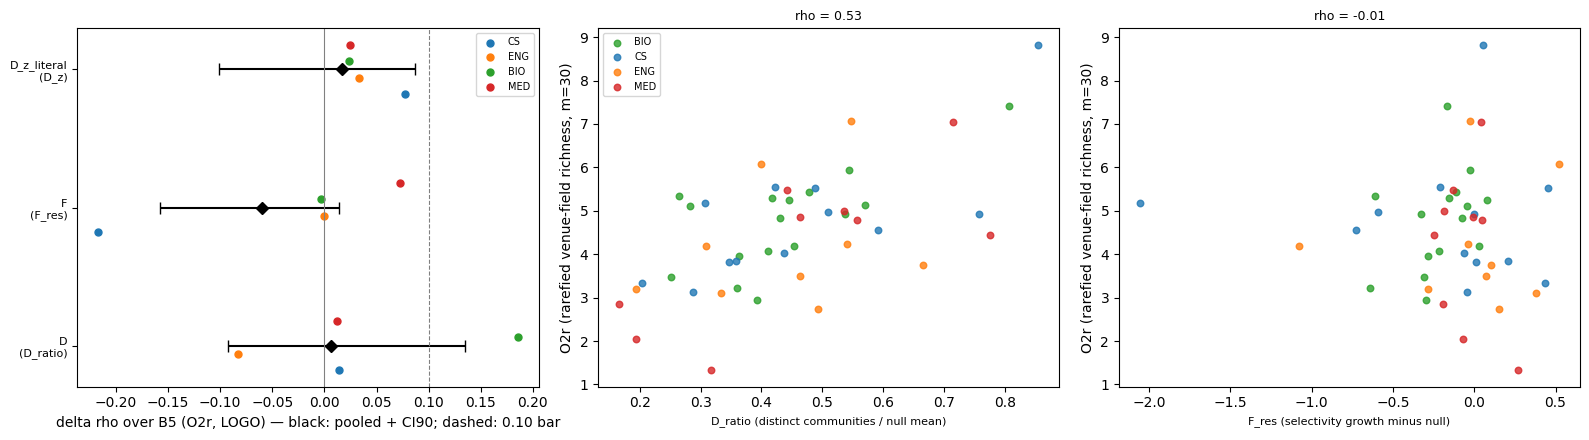

In [17]:
ref = data["reference_screen_result"]
rows = []
for key in PRIMARY:
    c, r = result["candidates"][key], ref["candidates"][key]
    rows.append({"candidate": f"{key} ({c['feature']})",
                 "delta_rho (demo)": round(c["delta_rho"], 4), "delta_rho (orig)": round(r["delta_rho"], 4),
                 "CI90 (demo, N_BOOT=%d)" % n_boot: [round(v, 3) for v in c["CI90"]],
                 "CI90 (orig, 2000)": [round(v, 3) for v in r["CI90"]],
                 "groups+": c["n_groups_positive"], "SB": round(c["reliability"]["SB_median"], 2),
                 "survives": c["survives"]})
print(f"B5 baseline LOGO rho(O2r): demo {result['base_metrics']['O2r']:.4f} | original {ref['base_metrics']['O2r']:.4f}")
print(pd.DataFrame(rows).to_string(index=False))
print("\nSelection criteria:")
print(pd.DataFrame({k: result["candidates"][k]["criteria"] for k in SCREENED}).to_string())
print("\nSurvivors:", result["survivors"], "| carried forward:", result["carried_forward"],
      "| original carried forward:", ref["carried_forward"])
pt = pd.DataFrame({k: {"pooled_rho_O2r": v["pooled_rho_O2r"], "logo_delta_rho_O2r": v.get("logo_delta_rho_O2r"),
                       "groups_same_sign": v["n_groups_same_sign_as_pooled"], "CS_only": v["negative_result_CS_only"]}
                   for k, v in result["portability"]["indicators"].items()}).T
print("\nPortability (top 10 indicators by |pooled rho with O2r|):")
print(pt.reindex(pt.pooled_rho_O2r.abs().sort_values(ascending=False).index).head(10).round(3).to_string())

GCOL = {"CS": "#1f77b4", "ENG": "#ff7f0e", "BIO": "#2ca02c", "MED": "#d62728"}
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
# (a) per-group delta rho with pooled CI
for i, key in enumerate(PRIMARY):
    c = result["candidates"][key]
    for j, g in enumerate(["CS", "ENG", "BIO", "MED"]):
        ax[0].scatter(c["per_group_delta_rho"].get(g, np.nan), i + (j - 1.5) * 0.12, color=GCOL[g], s=25,
                      label=g if i == 0 else None)
    ax[0].errorbar(c["delta_rho"], i, xerr=[[c["delta_rho"] - c["CI90"][0]], [c["CI90"][1] - c["delta_rho"]]],
                   fmt="D", color="k", capsize=4)
ax[0].axvline(0, color="grey", lw=0.8); ax[0].axvline(0.10, color="grey", ls="--", lw=0.8)
ax[0].set_yticks(range(len(PRIMARY))); ax[0].set_yticklabels([f"{k}\n({v})" for k, v in PRIMARY.items()], fontsize=8)
ax[0].set_xlabel("delta rho over B5 (O2r, LOGO) — black: pooled + CI90; dashed: 0.10 bar")
ax[0].legend(fontsize=7)
# (b), (c) candidates vs O2r
for a, c, lab in ((ax[1], "D_ratio", "D_ratio (distinct communities / null mean)"),
                  (ax[2], "F_res", "F_res (selectivity growth minus null)")):
    for g, dd in main_df.groupby("group"):
        a.scatter(dd[c], dd.O2r, s=22, alpha=0.8, color=GCOL.get(g, "k"), label=g)
    a.set_xlabel(lab, fontsize=8); a.set_ylabel("O2r (rarefied venue-field richness, m=30)")
    a.set_title(f"rho = {srho(main_df[c].to_numpy(float), main_df.O2r.to_numpy(float)):.2f}", fontsize=9)
ax[1].legend(fontsize=7)
fig.tight_layout()
plt.show()